[[0.99750445 0.30577158]
 [0.07601892 0.81769294]
 [0.38616017 0.00997173]
 [0.55839431 0.61570507]
 [0.74285197 0.135499  ]
 [0.32034311 0.74077278]
 [0.13935257 0.43155825]
 [0.81062448 0.94302005]
 [0.86833996 0.07725699]
 [0.19680862 0.55011404]
 [0.26484022 0.37130111]
 [0.68708962 0.75047016]
 [0.62201685 0.49682659]
 [0.44955376 0.87553966]
 [0.01067216 0.20304185]
 [0.93192881 0.67544293]
 [0.89776486 0.23722339]
 [0.03897674 0.63931209]
 [0.47004679 0.43921125]
 [0.58003944 0.93511194]
 [0.64312857 0.31368589]
 [0.28341064 0.81004232]
 [0.22319059 0.11143863]
 [0.83219236 0.51398307]
 [0.76861751 0.37980241]
 [0.15987517 0.99282658]
 [0.34867916 0.17944628]
 [0.70865655 0.69878244]
 [0.52227628 0.0539189 ]
 [0.41251257 0.57371485]
 [0.09455787 0.25401562]
 [0.9535749  0.86749959]
 [0.94130969 0.02116708]
 [0.11255082 0.60339999]
 [0.42771506 0.28762427]
 [0.50523698 0.83866727]
 [0.693578   0.41253945]
 [0.36584246 0.96312666]
 [0.17201641 0.14585337]
 [0.75050056 0.7276305 ]


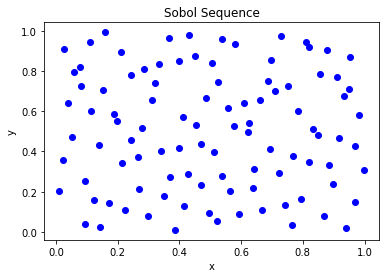

In [ ]:
#sobol sequence
import numpy as np
from scipy.stats import qmc
import matplotlib.pyplot as plt
import pandas as pd

d=2 #二维
sobol_sequence = qmc.Sobol(d=d, scramble=True) #Sobol 序列不是普通随机数，而是“低差异序列”，点会更均匀地铺在 [0, 1) x [0, 1) 的二维空间里，常用于 quasi-Monte Carlo 模拟。
n=100
samples = sobol_sequence.random(n)
print(samples)
df=pd.DataFrame(samples)
df.columns=['x','y']
plt.scatter(df['x'], df['y'],c='blue')
plt.title('Sobol Sequence')
plt.xlabel('x')
plt.ylabel('y')
plt.show()


In [ ]:
#bootstrapping: boots_f() function 抽样函数
import numpy as np
def boots_f(data, n_obs,replacement=None):#不放回抽样
    n=len(data)
    if (n<n_obs):
        print('n is less than n_obs')
    else:
        if replacement is None:
            y=np.random.permutation(data) #permutation()函数会随机打乱输入数据的顺序，返回一个新的数组。它不会修改原始数据。
            return y[:n_obs]
        else:
            y=[]
    for i in range(n_obs): #循环n_obs次，每次从data中随机抽取一个元素，放入y列表中，放回抽样
        k=np.random.permutation(data)
        y.append(k[0])
    return y

#test 
x=[1,2,3,4,5,0,-9,2,-10]
print(boots_f(x,6))
        

[ 4  0  2  3  1 -9]


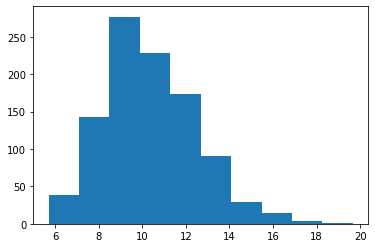

In [8]:
#simulate stock price movement
from math import exp, sqrt
import numpy.random as random
#import plot function
 
#input data
s0=9.15
t=1
n_steps=100
mu=0.15
sigma=0.2
random.seed(12345)
n_simulations=1000 #模拟次数
dt=t/n_steps

s=np.zeros([n_simulations],dtype=float)
x=np.arange(0,int(n_steps),1)
for j in np.arange(n_simulations):
    tt=s0
    for i in x[:-1]:
        e=random.normal()
        tt+=tt*(mu-0.5*sigma**2)*dt+sigma*tt*sqrt(dt)*e
        s[j]=tt
plt.hist(s)
plt.show()


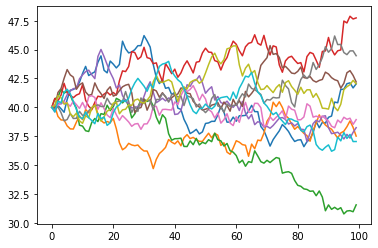

In [12]:
#path of stock price with a barrier
#input data
barrier=43
stock_price_today=40
t=0.5
n_steps=100
mu=0.05
sigma=0.2
random.seed(12345)
n_simulations=10
dt=t/n_steps
s=np.zeros([n_steps],dtype=float)
x=np.arange(0,int(n_steps),1)
for j in range(0,n_simulations):
    s[0]=stock_price_today
    for i in x[:-1]:
        e=random.normal()
        aa=sigma*s[i]*sqrt(dt)*e
        s[i+1]=s[i]+s[i]*(mu-0.5*sigma**2)*dt+aa
    plt.plot(x,s)
plt.show()
       


In [14]:
#chooser option : call or put
from scipy import stats
from math import exp, sqrt,log
def call_or_put(s,x,t,r,sigma,tao,type='C' ):
    d1=(log(s/x)+r*tao+0.5*sigma*sigma*tao)/sigma*sqrt(tao)
    d2=d1-sigma*sqrt(tao)
    if type=='C':
        price=s*stats.norm.cdf(d1)-x*exp(-r*t)*stats.norm.cdf(d2)
        return price
    else:
        price=x*exp(-r*t)*stats.norm.cdf(-d2)-s*stats.norm.cdf(-d1)
        return price
def chooser_option(s,x,t,r,sigma,tao):
    call_price=call_or_put(s,x,t,r,sigma,tao,'C')
    put_price=call_or_put(s,x,t,r,sigma,tao,'P')
    return call_price-put_price
s=40
x=40
t=0.5
tao=1/12
r=0.05
sigma=0.2
print(chooser_option(s,x,t,r,sigma,tao))
    


0.9876035188666918


In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis, shapiro, norm

# =========================
# 1. Data Preparation
# =========================


file_path = "/Users/liuyuxuan/Desktop/WMT12.pkl"
df = pd.read_pickle(file_path)

if isinstance(df.columns, pd.MultiIndex):
    close_prices = df["Close"].iloc[:, 0]
else:
    close_prices = df["Close"]

# 计算日收益率并删除缺失值
returns = close_prices.pct_change().dropna()

# =========================
# 2. Standard VaR
# =========================

portfolio_value = 100000
confidence_level = 0.99

mu_daily = returns.mean()
sigma_daily = returns.std()

z = norm.ppf(1 - confidence_level)  # about -2.326

# 1-Day VaR
var_1day = portfolio_value * abs(mu_daily + z * sigma_daily)

# 10-Day VaR
var_10day = portfolio_value * abs(
    mu_daily * 10 + z * sigma_daily * np.sqrt(10)
)

print("===== VaR Results =====")
print(f"1-Day VaR (99%): ${var_1day:.2f}")
print(f"10-Day VaR (99%): ${var_10day:.2f}")

# =========================
# 3. Normality Testing
# =========================

sample_skewness = skew(returns)
excess_kurtosis = kurtosis(returns, fisher=True)

print("\n===== Distribution Statistics =====")
print(f"Skewness: {sample_skewness:.4f}")
print(f"Excess Kurtosis: {excess_kurtosis:.4f}")

# Shapiro-Wilk Test
stat, p_value = shapiro(returns)

print("\n===== Shapiro-Wilk Test =====")
print(f"Statistic = {stat:.4f}")
print(f"P-value   = {p_value:.6f}")

if p_value > 0.05:
    print("Fail to reject H0: returns appear normally distributed.")
else:
    print("Reject H0: returns do NOT appear normally distributed.")


# =========================
# Question 2: Monte Carlo Simulation
# =========================

np.random.seed(12345)

S0 = 50
mu = 0.12
sigma = 0.25

T = 1
r = 0.05

n_paths = 5000
n_steps = 100

dt = T / n_steps

# =========================
# Monte Carlo Simulation
# =========================

prices = np.zeros((n_paths, n_steps + 1))
prices[:, 0] = S0

for i in range(n_paths):
    for t in range(1, n_steps + 1):
        z = np.random.normal()

        prices[i, t] = prices[i, t - 1] * np.exp(
            (mu - 0.5 * sigma**2) * dt
            + sigma * np.sqrt(dt) * z
        )

# =========================
# Terminal Prices
# =========================

terminal_prices = prices[:, -1]

# =========================
# Histogram
# =========================

plt.figure(figsize=(8, 5))
plt.hist(terminal_prices, bins=50, edgecolor="black")
plt.title("Distribution of Terminal Stock Prices")
plt.xlabel("Terminal Stock Price")
plt.ylabel("Frequency")
plt.show()

# =========================
# European Call Pricing
# =========================

X = 55

payoffs = np.maximum(terminal_prices - X, 0)

call_price = np.exp(-r * T) * np.mean(payoffs)

print("\n===== European Call Option =====")
print(f"Estimated Call Price = {call_price:.4f}")


ModuleNotFoundError: No module named 'numpy._core'

In [ ]:
portfolio_value = 100000
confidence_level = 0.99
